In [1]:
!pip install transformers accelerate sentencepiece fastdtw

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "microsoft/phi-2"  # start small

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    output_hidden_states=True,
    dtype=torch.float16,
    device_map="auto"
)


The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


In [3]:
import torch

def token_trajectory(text: str):
    tokens = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        out = model(**tokens)
    
    # hidden_states: tuple of (layer0, layer1, ..., layer_last)
    final_layer_hidden = out.hidden_states[-1][0]  # shape: [T, D]

    # Convert to list of CPU numpy vectors
    traj = [v.cpu().float().numpy() for v in final_layer_hidden]
    return traj


In [4]:
import torch

def token_trajectory(text: str):
    tokens = tokenizer(text, return_tensors="pt")
    print(tokens)
    traj = []

    for i in range(1, tokens["input_ids"].shape[1]+1):
        with torch.no_grad():
            out = model(input_ids=tokens["input_ids"][:, :i], attention_mask=tokens["attention_mask"][:, :i])
        # hidden_states: tuple of (layer0, layer1, ..., layer_last)
        final_layer_hidden = out.hidden_states[-1][0]  # shape: [T, D]

        # Convert to list of CPU numpy vectors
        traj.append(final_layer_hidden[-1].cpu().float().numpy())
    return traj


In [5]:
import numpy as np
from scipy.spatial.distance import cosine


def make_directional_vectors(traj):
    """
    Convert a trajectory into consecutive directional vectors.
    Each vector is the difference between consecutive embeddings.
    """
    directional_vectors = []
    for i in range(len(traj) - 1):
        # Calculate the vector *from* traj[i] *to* traj[i+1]
        vector = traj[i + 1] - traj[i]
        directional_vectors.append(vector)
    return directional_vectors

def span_l2_directional(vector1, vector2):
    # L2 distance still uses norm of the difference
    return np.linalg.norm(vector1 - vector2)

def span_cosine_directional(vector1, vector2):
    # Cosine distance still uses the scipy function
    return cosine(vector1, vector2)

def compare_trajectories_directional(traj1, traj2):
    """
    Compute pairwise distances between all spans of two trajectories.
    Returns matrices: L2 distances and cosine distances.
    """
    spans1 = make_directional_vectors(traj1)
    spans2 = make_directional_vectors(traj2)
    
    l2_matrix = np.zeros((len(spans1), len(spans2)))
    cos_matrix = np.zeros((len(spans1), len(spans2)))
    
    for i, s1 in enumerate(spans1):
        for j, s2 in enumerate(spans2):
            l2_matrix[i, j] = span_l2_directional(s1, s2)
            cos_matrix[i, j] = span_cosine_directional(s1, s2)
    
    return l2_matrix, cos_matrix

def make_spans(traj):
    """
    Convert a trajectory into consecutive spans.
    Each span is a pair of consecutive embeddings concatenated.
    """
    spans = []
    for i in range(len(traj) - 1):
        span = np.concatenate([traj[i], traj[i + 1]])
        spans.append(span)
    return spans

def span_l2(span1, span2):
    """
    L2 (Euclidean) distance between two spans.
    """
    return np.linalg.norm(span1 - span2)

def span_cosine(span1, span2):
    """
    Cosine distance (1 - cosine similarity) between two spans.
    """
    return cosine(span1, span2)

def compare_trajectories(traj1, traj2):
    """
    Compute pairwise distances between all spans of two trajectories.
    Returns matrices: L2 distances and cosine distances.
    """
    spans1 = make_spans(traj1)
    spans2 = make_spans(traj2)
    
    l2_matrix = np.zeros((len(spans1), len(spans2)))
    cos_matrix = np.zeros((len(spans1), len(spans2)))
    
    for i, s1 in enumerate(spans1):
        for j, s2 in enumerate(spans2):
            l2_matrix[i, j] = span_l2(s1, s2)
            cos_matrix[i, j] = span_cosine(s1, s2)
    
    return l2_matrix, cos_matrix

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_distance_matrices(l2_matrix, cos_matrix, traj1_name="Traj1", traj2_name="Traj2"):
    plt.figure(figsize=(14, 6))

    # L2 matrix heatmap
    plt.subplot(1, 2, 1)
    sns.heatmap(l2_matrix, cmap="viridis")
    plt.title(f"L2 Distance: {traj1_name} vs {traj2_name}")
    plt.xlabel(f"{traj2_name} spans")
    plt.ylabel(f"{traj1_name} spans")

    # Cosine matrix heatmap
    plt.subplot(1, 2, 2)
    sns.heatmap(cos_matrix, cmap="viridis")
    plt.title(f"Cosine Distance: {traj1_name} vs {traj2_name}")
    plt.xlabel(f"{traj2_name} spans")
    plt.ylabel(f"{traj1_name} spans")

    plt.tight_layout()
    plt.show()

{'input_ids': tensor([[  464,  4283,  1910, 14997,  7415]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])}
{'input_ids': tensor([[28065,   262,  5939,  5924,   257,  1688,  7794]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}


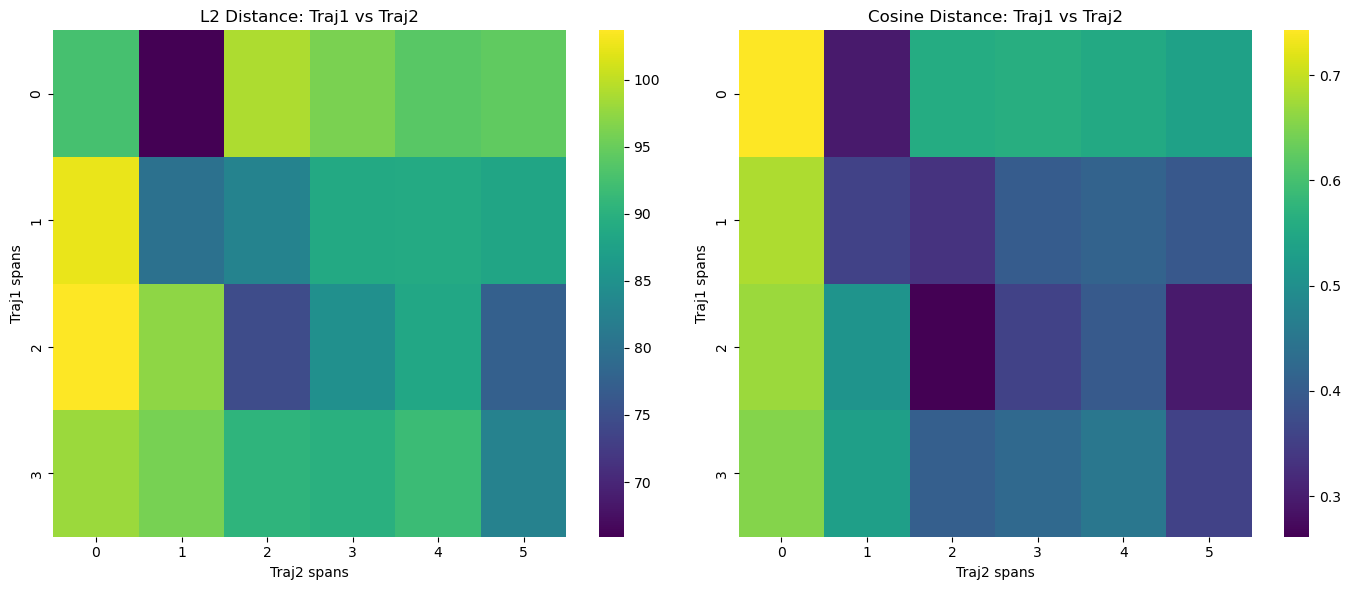

In [7]:
text1 = """The stock market crashed yesterday"""

text2 = """Yesterday the markets experienced a major decline"""


traj1 = token_trajectory(text1)
traj2 = token_trajectory(text2)

l2_matrix, cos_matrix = compare_trajectories(traj1, traj2)
visualize_distance_matrices(l2_matrix, cos_matrix)

{'input_ids': tensor([[  464,  4283,  1910, 14997,  7415]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])}
{'input_ids': tensor([[28065,   262,  5939,  5924,   257,  1688,  7794]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}


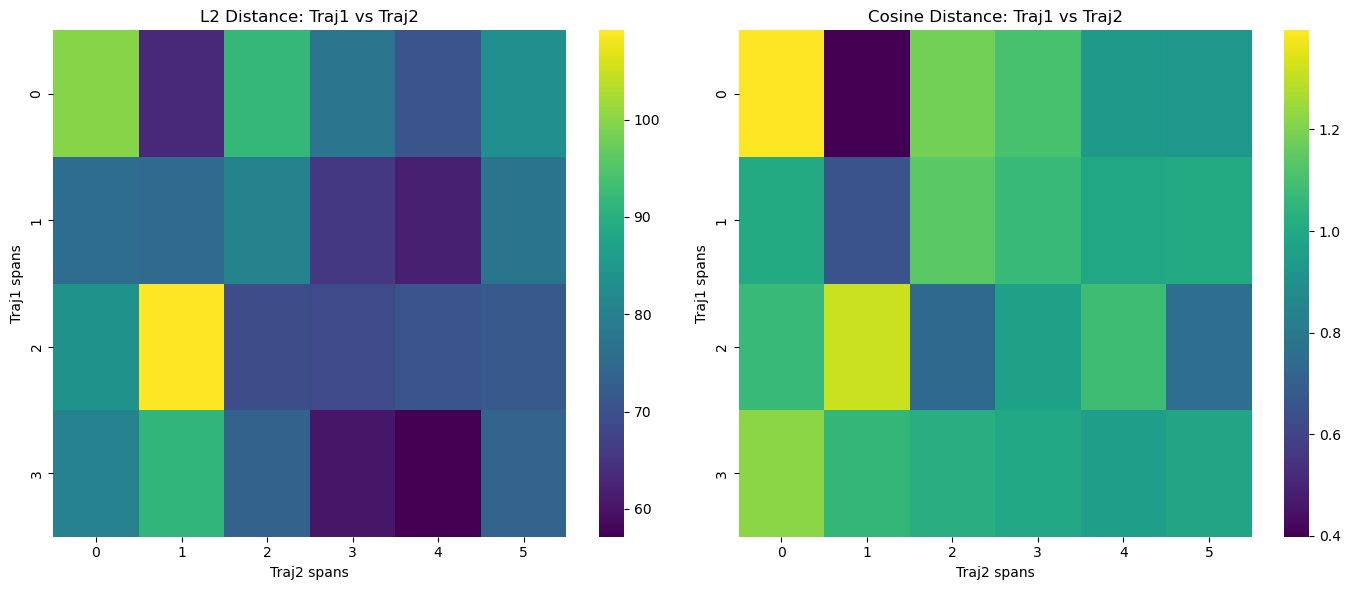

In [8]:

traj1 = token_trajectory(text1)
traj2 = token_trajectory(text2)
l2_matrix, cos_matrix = compare_trajectories_directional(traj1, traj2)
visualize_distance_matrices(l2_matrix, cos_matrix)

In [9]:
def make_token_spans(traj, tokens):
    """
    Create spans from embeddings and keep token labels.
    
    traj: list of embeddings [H0, H1, ...]
    tokens: list of token strings ['Hummer', 'is', ...]
    
    Returns list of dicts: {"span_embedding": ..., "tokens": (token_i, token_i+1)}
    """
    spans = []
    for i in range(len(traj) - 1):
        span_emb = np.concatenate([traj[i], traj[i + 1]])
        spans.append({
            "span_embedding": span_emb,
            "tokens": (tokens[i], tokens[i + 1])
        })
    return spans

def compare_token_trajectories(traj1, tokens1, traj2, tokens2):
    spans1 = make_token_spans(traj1, tokens1)
    spans2 = make_token_spans(traj2, tokens2)

    l2_matrix = np.zeros((len(spans1), len(spans2)))
    cos_matrix = np.zeros((len(spans1), len(spans2)))

    for i, s1 in enumerate(spans1):
        for j, s2 in enumerate(spans2):
            l2_matrix[i, j] = span_l2(s1["span_embedding"], s2["span_embedding"])
            cos_matrix[i, j] = span_cosine(s1["span_embedding"], s2["span_embedding"])

    return l2_matrix, cos_matrix, spans1, spans2

In [10]:
text1 = """The stock market crashed yesterday."""

text2 = """Yesterday the markets experienced a major decline. The stock market crashed yesterday. The stock market crashed yesterday. The stock market crashed yesterday."""

tokens1 = tokenizer.tokenize(text1)
tokens2 = tokenizer.tokenize(text2)

traj1 = token_trajectory(text1)
traj2 = token_trajectory(text2)

l2_matrix, cos_matrix, spans1, spans2 = compare_token_trajectories(traj1, tokens1, traj2, tokens2)

# Example: print first 3 span labels
for s in spans1:
    print(s["tokens"])

{'input_ids': tensor([[  464,  4283,  1910, 14997,  7415,    13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}
{'input_ids': tensor([[28065,   262,  5939,  5924,   257,  1688,  7794,    13,   383,  4283,
          1910, 14997,  7415,    13,   383,  4283,  1910, 14997,  7415,    13,
           383,  4283,  1910, 14997,  7415,    13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1]])}
('The', 'Ġstock')
('Ġstock', 'Ġmarket')
('Ġmarket', 'Ġcrashed')
('Ġcrashed', 'Ġyesterday')
('Ġyesterday', '.')


In [11]:
def visualize_distance_matrices_with_tokens(l2_matrix, cos_matrix, spans1, spans2):
    """
    Visualize L2 and Cosine distance matrices with token labels on axes.
    
    spans1, spans2: list of dicts with 'tokens' key
    """
    # Prepare labels for axes: join token pairs
    labels1 = [" ".join(s["tokens"]) for s in spans1]
    labels2 = [" ".join(s["tokens"]) for s in spans2]

    plt.figure(figsize=(16, 8))

    # L2 distance heatmap
    plt.subplot(1, 2, 1)
    sns.heatmap(l2_matrix, cmap="viridis", xticklabels=labels2, yticklabels=labels1, vmin=0, vmax=200)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.title("L2 Distance")

    # Cosine distance heatmap
    plt.subplot(1, 2, 2)
    sns.heatmap(cos_matrix, cmap="viridis", xticklabels=labels2, yticklabels=labels1, vmin=0, vmax=1)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.title("Cosine Distance")

    plt.tight_layout()
    plt.show()


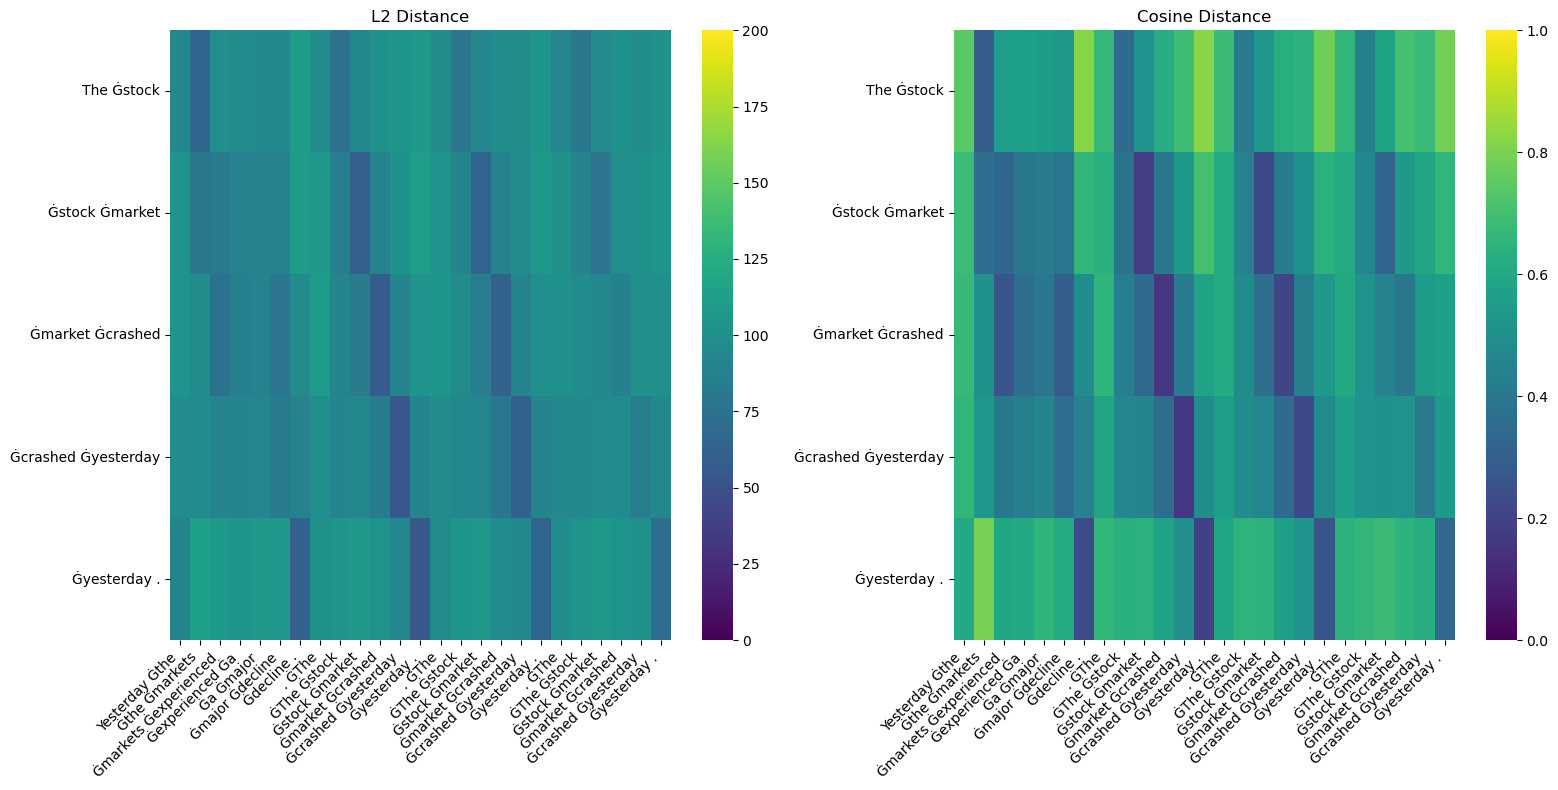

In [12]:
visualize_distance_matrices_with_tokens(l2_matrix, cos_matrix, spans1, spans2)
